# 프로젝트 : Seq2Seq으로 한국어 번역기 만들기
### 프로젝트 제출 루브릭

|학습목표|평가기준|
|---|---|
|번역기 모델 학습에 필요한 텍스트 데이터 전처리가 한국어 포함하여 잘 이루어졌다.|구두점, 대소문자, 띄어쓰기, 한글 형태소분석 등 번역기 모델에 요구되는 전처리가 정상적으로 진행되었다.|
|Attentional Seq2seq 모델이 정상적으로 구동된다.|seq2seq 모델 훈련 과정에서 training loss가 안정적으로 떨어지면서 학습이 진행됨이 확인되었다|
|테스트 결과 의미가 통하는 수준의 번역문이 생성되었다.|테스트용 디코더 모델이 정상적으로 만들어져서, 정답과 어느 정도 유사한 영어 번역이 진행됨을 확인하였다.|

## 프로젝트 요약: Seq2Seq 한국어 번역기

이 노트북은 Seq2Seq 모델을 사용하여 한국어를 영어로 번역하는 과정을 구현하고 있습니다. 주요 단계는 다음과 같습니다.

### 1. 환경 설정 및 라이브러리 설치

*   한국어 형태소 분석을 위해 `KoNLPy`와 `Mecab`을 설치하고 설정합니다.
*   Colab 환경에서 `torch.load`의 호환성 문제를 해결하는 패치를 적용합니다.
*   한글 폰트 (`NanumBarunGothic`)를 설치하고 `matplotlib`에 적용하여 그래프에서 한글이 올바르게 표시되도록 설정합니다.
*   사용 중인 `pandas`, `torch`, `matplotlib`의 버전을 확인합니다.

### 2. 데이터 다운로드 및 전처리

*   `korean-english-park.train.tar.gz` 파일을 다운로드하여 한국어-영어 병렬 데이터를 확보합니다.
*   다운로드된 한국어 (`korean-english-park.train.ko`)와 영어 (`korean-english-park.train.en`) 파일을 로드합니다.
*   데이터 정제 함수 (`preprocess_sentence`)를 정의하여 다음을 수행합니다:
    *   구두점, 대소문자, 불필요한 문자 제거.
    *   한국어 문장은 `Mecab`을 이용해 형태소 단위로 토큰화합니다.
    *   영어 문장에는 `<start>` 및 `<end>` 토큰을 추가합니다.
*   중복 데이터를 제거하고, 토큰 길이가 40 이하인 문장 쌍만 필터링하여 `kor_corpus`와 `eng_corpus`를 구축합니다.

### 3. 데이터 토큰화 및 텐서 변환

*   `tensorflow.keras.preprocessing.text.Tokenizer`를 사용하여 한국어와 영어 코퍼스를 토큰화하고 각 언어의 단어 집합 (`kor_tokenizer`, `eng_tokenizer`)을 생성합니다.
*   토큰화된 시퀀스를 패딩하여 고정된 길이의 텐서 (`kor_tensor`, `eng_tensor`)로 변환합니다.
*   어휘 크기를 10,000 이상으로 설정하고, 실제 어휘 크기와 텐서의 형태를 출력하여 확인합니다.

### 4. Seq2Seq 모델 설계

*   `torch` 라이브러리를 사용하여 Seq2Seq 모델의 구성 요소를 정의합니다.
*   **인코더 (Encoder):** `nn.GRU`를 기반으로 입력 시퀀스를 임베딩하고 은닉 상태로 압축합니다.
*   **어텐션 메커니즘 (Bahdanau Attention):** 디코더가 출력 단어를 예측할 때 인코더의 모든 출력에 가중치를 부여하는 `BahdanauAttention`을 구현합니다.
*   **디코더 (Decoder):** `nn.GRU`와 어텐션 메커니즘을 사용하여 타겟 시퀀스를 생성합니다.
*   **Seq2Seq 모델:** 인코더와 디코더를 통합하여 `teacher forcing`을 적용할 수 있도록 설계합니다.
*   하이퍼파라미터 (예: `embedding_dim`, `units`, `BATCH_SIZE`)를 설정하고, `CUDA` 사용 가능 여부를 확인합니다.

### 5. 모델 훈련

*   `TensorDataset`과 `DataLoader`를 사용하여 훈련 데이터를 준비합니다.
*   인코더, 디코더, Seq2Seq 모델을 초기화하고, `Adam` 옵티마이저와 `CrossEntropyLoss`를 정의합니다.
*   훈련 스텝 (`train_step`) 및 평가 스텝 (`eval_step`) 함수를 정의합니다.
*   번역 테스트 함수 (`translate_sentence`)를 정의하여 훈련 중 모델의 번역 성능을 확인합니다.
*   메인 훈련 루프에서 `EPOCHS`만큼 모델을 훈련하며, 각 에포크마다 훈련 손실과 검증 손실을 기록하고 예제 문장 번역 결과를 출력합니다.
*   훈련 완료 후, 훈련 손실과 검증 손실을 시각화하고, 특정 예제 문장에 대한 어텐션 맵을 시각화하여 모델의 작동 방식을 분석합니다.

### KoNLPy 및 MeCab 설치
한글 텍스트 전처리를 위해 KoNLPy와 MeCab을 설치합니다. 이는 한국어 형태소 분석에 필수적입니다.

In [79]:
# # 기존 MeCab 관련 패키지 제거 (충돌 방지)
# !apt-get remove -y mecab libmecab-dev mecab-python mecab-ko-dic
# !pip uninstall -y konlpy mecab-python3

# # MeCab-ko-for-Google-Colab 스크립트 다운로드
# !git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git

# # 올바른 설치 스크립트 실행 (최신 버전 사용)
# # `install_mecab-ko_on_colab_light_220429.sh` 또는 `install_mecab-ko_on_colab190912.sh` 중 상황에 맞는 것을 선택
# # 여기서는 `install_mecab-ko_on_colab_light_220429.sh`를 사용합니다.
# !bash Mecab-ko-for-Google-Colab/install_mecab-ko_on_colab_light_220429.sh

# # konlpy 및 mecab-python3 재설치 (최신 환경에 맞춤)
# !pip install konlpy
# !pip install mecab-python3

# print("MeCab 및 한국어 사전 설치 완료. 런타임 재시작 후 진행해주세요.")

# # 설치 후 런타임 재시작이 필요합니다. (런타임 -> 런타임 다시 시작)

In [80]:
# from google.colab import drive
# drive.mount('/content/drive')

In [81]:
# === Colab 호환 셋업 (자동 추가) ===
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치 적용')

[colab-compat] torch.load weights_only=False 패치 적용


In [82]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.


In [83]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [84]:
import pandas
import torch
import matplotlib

print(pandas.__version__)
print(torch.__version__)
print(matplotlib.__version__)

2.2.3
2.11.0+cu128
3.10.0


## Step 1. 데이터 다운로드

아래 링크에서 korean-english-park.train.tar.gz 를 다운로드받아 한영 병렬 데이터를 확보합니다.

https://github.com/jungyeul/korean-parallel-corpora/tree/master/korean-english-news-v1

In [85]:
import os

# 데이터 다운로드 및 압축 해제
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
!tar -xvf korean-english-park.train.tar.gz

# 파일 경로 설정
kor_path = "korean-english-park.train.ko"
eng_path = "korean-english-park.train.en"

# 파일이 존재하는지 확인
if os.path.exists(kor_path) and os.path.exists(eng_path):
    print(f"한국어 파일: {kor_path} 존재합니다.")
    print(f"영어 파일: {eng_path} 존재합니다.")
else:
    print("파일 다운로드 또는 압축 해제에 실패했습니다.")

--2026-09-09 10:25:09--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-09-09 10:25:09--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [application/octet-stream]
Saving to: ‘korean-english-park.train.tar.gz.6’

kore

## Step 2. 데이터 정제
set 데이터형이 중복을 허용하지 않는다는 것을 활용해 중복된 데이터를 제거하도록 합니다. 데이터의 병렬 쌍이 흐트러지지 않게 주의하세요! 중복을 제거한 데이터를 cleaned_corpus 에 저장합니다.

앞서 정의한 preprocessing() 함수는 한글에서는 동작하지 않습니다. 한글에 적용할 수 있는 정규식을 추가하여 함수를 재정의하세요!

타겟 언어인 영문엔 <start> 토큰과 <end> 토큰을 추가하고 split() 함수를 이용하여 토큰화합니다. 한글 토큰화는 KoNLPy의 mecab 클래스를 사용합니다.

모든 데이터를 사용할 경우 학습에 굉장히 오랜 시간이 걸립니다. cleaned_corpus로부터 토큰의 길이가 40 이하인 데이터를 선별하여 eng_corpus와 kor_corpus를 각각 구축하세요.

In [86]:
# Load raw data
with open(kor_path, 'r', encoding='utf-8') as f:
    raw_kor = f.read().splitlines()
with open(eng_path, 'r', encoding='utf-8') as f:
    raw_eng = f.read().splitlines()

print(f"Original Korean sentences: {len(raw_kor)}")
print(f"Original English sentences: {len(raw_eng)}")


Original Korean sentences: 94123
Original English sentences: 94123


In [87]:
import re
from konlpy.tag import Mecab
mecab = Mecab()

def preprocess_sentence(sentence, is_korean=False):
    sentence = sentence.lower().strip()
    # Delete the unwanted punctuation marks
    sentence = re.sub(r"([?.!,¿])", r" \1 ", sentence)
    sentence = re.sub(r'[""“”‘’]', '', sentence)
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,¿]+", r" ", sentence)
    sentence = sentence.strip()

    if is_korean:
        # Korean tokenization using MeCab
        tokens = mecab.morphs(sentence)
        sentence = ' '.join(tokens)
    else:
        # English preprocessing and add start/end tokens
        sentence = '<start> ' + sentence + ' <end>'

    return sentence

print("Preprocessing function defined.")

Preprocessing function defined.


### 데이터 정제 및 필터링
중복을 제거하고, 토큰 길이가 40 이하인 문장 쌍만 선택하여 `cleaned_corpus`, `kor_corpus`, `eng_corpus`를 생성합니다.

In [88]:
cleaned_corpus = set()

for kor_sen, eng_sen in zip(raw_kor, raw_eng):
    # Preprocess sentences
    preprocessed_kor = preprocess_sentence(kor_sen, is_korean=True)
    preprocessed_eng = preprocess_sentence(eng_sen, is_korean=False)

    # Check length constraint (token count <= 40)
    if len(preprocessed_kor.split()) <= 40 and len(preprocessed_eng.split()) <= 40:
        cleaned_corpus.add((preprocessed_kor, preprocessed_eng))

# Convert set to list and split into separate corpora
kor_corpus = []
eng_corpus = []
for kor, eng in list(cleaned_corpus):
    kor_corpus.append(kor)
    eng_corpus.append(eng)

print(f"Cleaned and filtered Korean sentences: {len(kor_corpus)}")
print(f"Cleaned and filtered English sentences: {len(eng_corpus)}")

# Display first 5 examples
print("\n--- First 5 cleaned examples ---")
for i in range(5):
    print(f"K: {kor_corpus[i]}")
    print(f"E: {eng_corpus[i]}")

Cleaned and filtered Korean sentences: 62819
Cleaned and filtered English sentences: 62819

--- First 5 cleaned examples ---
K: 미 국방부 는 이 예비 평가 보고서 에서 미군 증강 초기 의 효과 를 부각 하 는 데 중점 을 둔 것 으로 알려졌 다 .
E: <start> a pentagon spokesman admits the report will show that not many if any of the benchmarks for progress have been met . <end>
K: 총기 난사 의 범인 인 로버트 스튜어트 는 폭력 성향 을 가진 사람 이 라고 그 의 전 부인 이 밝혔 습니다 .
E: <start> the ex wife of the accused shooter says that robert stewart could be a violent man <end>
K: 경찰 은 용의자 들 을 덴마크 서부 의 오르후스 에서 새벽 무렵 붙잡 았 으며 아직 실명 을 공개 하 지 않 았 다 .
E: <start> the operation took place in the aarhus area of western denmark at a . m . local time following lengthy surveillance , the intelligence service said . <end>
K: 안보리 의장 은 회의 를 주제 하 고 새로운 아젠다 를 제시 하 지만 안보리 의장 이 된다고 해서 그 국가 가 상임 이사국 이 되 는 것 은 아니 다 .
E: <start> the job requires setting the monthly agenda and running council meetings , but it does not give an ambassador automatic entry into talks exclusive to the most powerful

## Step 3. 데이터 토큰화

앞서 정의한 tokenize() 함수를 사용해 데이터를 텐서로 변환하고 각각의 tokenizer를 얻으세요! 단어의 수는 실험을 통해 적당한 값을 맞춰주도록 합니다! (최소 10,000 이상!)

❗ 주의: 난이도에 비해 데이터가 많지 않아 훈련 데이터와 검증 데이터를 따로 나누지는 않습니다.

In [89]:
import tensorflow as tf

def tokenize(corpus, vocab_size):
    # Create a tokenizer
    tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=vocab_size, filters='', oov_token='<unk>')
    # Fit the tokenizer on the corpus
    tokenizer.fit_on_texts(corpus)

    # Convert texts to sequences
    tensor = tokenizer.texts_to_sequences(corpus)

    # Pad sequences to ensure uniform length
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding='post')

    return tensor, tokenizer

# Define vocabulary size based on the instruction (minimum 10,000)
VOCAB_SIZE_KOR = 10000
VOCAB_SIZE_ENG = 10000
# VOCAB_SIZE_KOR = 20000  # You can adjust this based on experimentation
# VOCAB_SIZE_ENG = 20000  # You can adjust this based on experimentation

# Tokenize Korean corpus
kor_tensor, kor_tokenizer = tokenize(kor_corpus, VOCAB_SIZE_KOR)

# Tokenize English corpus
eng_tensor, eng_tokenizer = tokenize(eng_corpus, VOCAB_SIZE_ENG)

print(f"Korean Vocabulary Size: {len(kor_tokenizer.word_index)}")
print(f"English Vocabulary Size: {len(eng_tokenizer.word_index)}")
print(f"Korean Tensor Shape: {kor_tensor.shape}")
print(f"English Tensor Shape: {eng_tensor.shape}")

# Example of tokenized and padded sentences
print("\n--- First 5 tokenized Korean examples ---")
for i in range(5):
    print(f"Original: {kor_corpus[i]}")
    print(f"Tokenized: {kor_tensor[i]}")

print("\n--- First 5 tokenized English examples ---")
for i in range(5):
    print(f"Original: {eng_corpus[i]}")
    print(f"Tokenized: {eng_tensor[i]}")

Korean Vocabulary Size: 44145
English Vocabulary Size: 38554
Korean Tensor Shape: (62819, 40)
English Tensor Shape: (62819, 40)

--- First 5 tokenized Korean examples ---
Original: 미 국방부 는 이 예비 평가 보고서 에서 미군 증강 초기 의 효과 를 부각 하 는 데 중점 을 둔 것 으로 알려졌 다 .
Tokenized: [  81  808    5    4 1529  903  366   16  158 3923 1656    7 1395   11
 6492   12    5  211 6217    6 1847   22   21  577    3    2    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]
Original: 총기 난사 의 범인 인 로버트 스튜어트 는 폭력 성향 을 가진 사람 이 라고 그 의 전 부인 이 밝혔 습니다 .
Tokenized: [1144 1901    7 1151   24 1036 4353    5  533 2242    6  659   76    4
   36   25    7   56  450    4   40   50    2    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]
Original: 경찰 은 용의자 들 을 덴마크 서부 의 오르후스 에서 새벽 무렵 붙잡 았 으며 아직 실명 을 공개 하 지 않 았 다 .
Tokenized: [  70    8  417   15    6 2568  944    7    1   16 2862 3446 5344   52
   98  233 7527    6  280   12   30   42   52    3    2    0    0    0
    0    0    0   

In [90]:
from sklearn.model_selection import train_test_split

# Training/Validation split ratio
TRAIN_SPLIT_RATIO = 0.8

# Split data into training and validation sets
kor_train, kor_val, eng_train, eng_val = train_test_split(
    kor_tensor, eng_tensor, test_size=(1-TRAIN_SPLIT_RATIO), random_state=42)

print(f"Korean Train Tensor Shape: {kor_train.shape}")
print(f"English Train Tensor Shape: {eng_train.shape}")
print(f"Korean Validation Tensor Shape: {kor_val.shape}")
print(f"English Validation Tensor Shape: {eng_val.shape}")

Korean Train Tensor Shape: (50255, 40)
English Train Tensor Shape: (50255, 40)
Korean Validation Tensor Shape: (12564, 40)
English Validation Tensor Shape: (12564, 40)


In [91]:
from torch.utils.data import TensorDataset, DataLoader

# Create TensorDataset and DataLoader for training
train_dataset = TensorDataset(torch.LongTensor(kor_train).to(device), torch.LongTensor(eng_train).to(device))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Create TensorDataset and DataLoader for validation
val_dataset = TensorDataset(torch.LongTensor(kor_val).to(device), torch.LongTensor(eng_val).to(device))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False) # No shuffle for validation

print("Train and Validation Datasets and DataLoaders prepared.")

Train and Validation Datasets and DataLoaders prepared.


In [92]:
from sklearn.model_selection import train_test_split

# Training/Validation split ratio
TRAIN_SPLIT_RATIO = 0.8

# Split data into training and validation sets
kor_train, kor_val, eng_train, eng_val = train_test_split(
    kor_tensor, eng_tensor, test_size=(1-TRAIN_SPLIT_RATIO), random_state=42)

print(f"Korean Train Tensor Shape: {kor_train.shape}")
print(f"English Train Tensor Shape: {eng_train.shape}")
print(f"Korean Validation Tensor Shape: {kor_val.shape}")
print(f"English Validation Tensor Shape: {eng_val.shape}")

Korean Train Tensor Shape: (50255, 40)
English Train Tensor Shape: (50255, 40)
Korean Validation Tensor Shape: (12564, 40)
English Validation Tensor Shape: (12564, 40)


In [93]:
from torch.utils.data import TensorDataset, DataLoader

# Create TensorDataset and DataLoader for training
train_dataset = TensorDataset(torch.LongTensor(kor_train).to(device), torch.LongTensor(eng_train).to(device))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Create TensorDataset and DataLoader for validation
val_dataset = TensorDataset(torch.LongTensor(kor_val).to(device), torch.LongTensor(eng_val).to(device))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False) # No shuffle for validation

print("Train and Validation Datasets and DataLoaders prepared.")

Train and Validation Datasets and DataLoaders prepared.


## Step 4. 모델 설계
한국어를 영어로 잘 번역해 줄 멋진 Attention 기반 Seq2seq 모델을 설계하세요! Embedding Size와 Hidden Size는 실험을 통해 적당한 값을 맞춰 주도록 합니다

In [94]:
import torch
import torch.nn as nn
import random

# Hyperparameters (Adjust these as needed)
embedding_dim = 256
units = 512  # Hidden size (enc_units and dec_units)
# BATCH_SIZE = 64
BATCH_SIZE = 32  # Ablation Study 3: 배치 크기를 64에서 32로 조정하여 안정성 테스트

# Calculate maximum sequence length for Korean and English
max_kor_len = kor_tensor.shape[1]
max_eng_len = eng_tensor.shape[1]

# Get vocabulary sizes from tokenizers
# Use the defined VOCAB_SIZE and add 1 for padding/OOV token
# Note: tf.keras.preprocessing.text.Tokenizer's num_words limits the vocabulary used for sequences,
# but its word_index attribute contains all unique words found. So, the effective vocab size
# for the Embedding layer should be based on the num_words limit + 1 (for padding/OOV).
kor_vocab_size = VOCAB_SIZE_KOR + 1
eng_vocab_size = VOCAB_SIZE_ENG + 1

print(f"Korean Max Seq Length: {max_kor_len}")
print(f"English Max Seq Length: {max_eng_len}")
print(f"Korean Vocab Size (capped): {kor_vocab_size}")
print(f"English Vocab Size (capped): {eng_vocab_size}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Korean Max Seq Length: 40
English Max Seq Length: 40
Korean Vocab Size (capped): 10001
English Vocab Size (capped): 10001
Using device: cuda


In [95]:
# Training/Validation split ratio
TRAIN_SPLIT_RATIO = 0.8

# Dropout rate for regularization
DROPOUT_RATE = 0.3

print(f"Training Split Ratio: {TRAIN_SPLIT_RATIO}")
print(f"Dropout Rate: {DROPOUT_RATE}")

Training Split Ratio: 0.8
Dropout Rate: 0.3


In [96]:
# Training/Validation split ratio
TRAIN_SPLIT_RATIO = 0.8

# Dropout rate for regularization
DROPOUT_RATE = 0.3

print(f"Training Split Ratio: {TRAIN_SPLIT_RATIO}")
print(f"Dropout Rate: {DROPOUT_RATE}")

Training Split Ratio: 0.8
Dropout Rate: 0.3


### Encoder (인코더)
인코더는 입력 시퀀스(한국어 문장)를 고정된 길이의 컨텍스트 벡터 또는 일련의 은닉 상태로 변환하여 입력 정보의 핵심을 압축하는 역할을 합니다.

In [97]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, enc_units, batch_sz):
        super(Encoder, self).__init__()
        self.batch_sz = batch_sz
        self.enc_units = enc_units
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # Changed to bidirectional=True
        self.gru = nn.GRU(embedding_dim, self.enc_units,
                          batch_first=True,
                          bidirectional=True) # Changed to True

    def forward(self, x, hidden):
        x = self.embedding(x) # (batch_size, seq_len, embedding_dim)
        # output: (batch_size, seq_len, 2 * enc_units) for bidirectional
        # state: (2, batch_size, enc_units) for bidirectional (forward and backward states)
        output, state = self.gru(x, hidden)

        # Combine forward and backward hidden states to pass to the decoder
        # Summing them up is a common way to get a single context vector for the decoder
        # (1, batch_size, enc_units)
        combined_state = torch.sum(state, dim=0, keepdim=True)

        return output, combined_state

    def initialize_hidden_state(self, batch_size=None):
        if batch_size is None:
            batch_size = self.batch_sz
        # For bidirectional GRU, initial hidden state needs 2 layers (forward and backward)
        return torch.zeros((2, batch_size, self.enc_units)).to(device)

In [98]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, enc_units, batch_sz, dropout_rate):
        super(Encoder, self).__init__()
        self.batch_sz = batch_sz
        self.enc_units = enc_units
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.dropout = nn.Dropout(dropout_rate) # Add dropout
        self.gru = nn.GRU(embedding_dim, self.enc_units,
                          batch_first=True,
                          bidirectional=True)

    def forward(self, x, hidden):
        x = self.embedding(x)
        x = self.dropout(x) # Apply dropout after embedding
        output, state = self.gru(x, hidden)
        combined_state = torch.sum(state, dim=0, keepdim=True)
        return output, combined_state

    def initialize_hidden_state(self, batch_size=None):
        if batch_size is None:
            batch_size = self.batch_sz
        return torch.zeros((2, batch_size, self.enc_units)).to(device)

print("Encoder class updated with Dropout.")

Encoder class updated with Dropout.


### Attention (어텐션 메커니즘)
디코더가 출력 단어를 예측할 때 인코더의 모든 출력에 가중치를 부여합니다. 여기서는 Bahdanau Attention을 구현합니다.

In [99]:
class BahdanauAttention(nn.Module):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = nn.Linear(units, units) # For decoder hidden state
        # Changed W2 input features to 2*units because encoder output is now bidirectional (2*enc_units)
        self.W2 = nn.Linear(units * 2, units) # For encoder output values
        self.V = nn.Linear(units, 1)

    def forward(self, query, values): # query is decoder_hidden_state, values are encoder_outputs
        # query shape == (batch_size, hidden_size) --> decoder_hidden_state (dec_units)
        # values shape == (batch_size, max_len, 2 * hidden_size) --> encoder_outputs (2*enc_units)

        # query_with_time_axis shape == (batch_size, 1, hidden_size)
        query_with_time_axis = query.unsqueeze(1)

        # score shape == (batch_size, max_len, 1)
        # We need to make sure the dimensions match for the sum: (batch_size, 1, units) + (batch_size, max_len, units)
        # W2(values) will transform (batch_size, max_len, 2*units) to (batch_size, max_len, units)
        score = self.V(torch.tanh(self.W1(query_with_time_axis) + self.W2(values)))

        # attention_weights shape == (batch_size, max_len, 1)
        attention_weights = torch.softmax(score, dim=1)

        # context_vector shape == (batch_size, 1, hidden_size) --> after sum (batch_size, hidden_size)
        context_vector = attention_weights * values
        context_vector = torch.sum(context_vector, dim=1)

        return context_vector, attention_weights

print("BahdanauAttention class defined.")

BahdanauAttention class defined.


### Decoder (디코더)
디코더는 어텐션 메커니즘의 도움을 받아 번역된 시퀀스를 생성합니다. 여기서는 GRU를 사용합니다.

In [100]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, dec_units, batch_sz):
        super(Decoder, self).__init__()
        self.batch_sz = batch_sz
        self.dec_units = dec_units
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # Corrected input size for GRU: embedding_dim + (2 * dec_units) because context_vector is now 2*units
        self.gru = nn.GRU(embedding_dim + (2 * dec_units), self.dec_units, batch_first=True)
        self.fc = nn.Linear(dec_units, vocab_size)
        self.attention = BahdanauAttention(self.dec_units)

    def forward(self, x, hidden, enc_output):
        # enc_output shape == (batch_size, max_len, hidden_size)

        context_vector, attention_weights = self.attention(hidden.squeeze(0), enc_output)

        # x shape == (batch_size, 1, embedding_dim)
        x = self.embedding(x)

        # x shape == (batch_size, 1, embedding_dim + hidden_size)
        x = torch.cat((context_vector.unsqueeze(1), x), dim=-1)

        # passing the concatenated vector to the GRU
        output, state = self.gru(x, hidden) # output: (batch_size, 1, dec_units), state: (1, batch_size, dec_units)

        # output shape == (batch_size * 1, dec_units)
        output = output.view(-1, output.size(2))

        # output shape == (batch_size, vocab)
        x = self.fc(output)

        return x, state, attention_weights

    def initialize_hidden_state(self, batch_size=None):
        if batch_size is None:
            batch_size = self.batch_sz
        return torch.zeros((1, batch_size, self.dec_units)).to(device)

In [101]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, dec_units, batch_sz, dropout_rate):
        super(Decoder, self).__init__()
        self.batch_sz = batch_sz
        self.dec_units = dec_units
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.dropout = nn.Dropout(dropout_rate) # Add dropout
        self.gru = nn.GRU(embedding_dim + (2 * dec_units), self.dec_units, batch_first=True)
        self.fc = nn.Linear(dec_units, vocab_size)
        self.attention = BahdanauAttention(self.dec_units)

    def forward(self, x, hidden, enc_output):
        context_vector, attention_weights = self.attention(hidden.squeeze(0), enc_output)
        x = self.embedding(x)
        x = self.dropout(x) # Apply dropout after embedding
        x = torch.cat((context_vector.unsqueeze(1), x), dim=-1)
        output, state = self.gru(x, hidden)
        output = output.view(-1, output.size(2))
        x = self.fc(output)
        return x, state, attention_weights

    def initialize_hidden_state(self, batch_size=None):
        if batch_size is None:
            batch_size = self.batch_sz
        return torch.zeros((1, batch_size, self.dec_units)).to(device)

print("Decoder class updated with Dropout.")

Decoder class updated with Dropout.


In [102]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, input_tensor, target_tensor, teacher_forcing_ratio=0.5):
        # input_tensor: (batch_size, enc_seq_len)
        # target_tensor: (batch_size, dec_seq_len)

        batch_size = input_tensor.size(0)
        target_len = target_tensor.size(1)
        target_vocab_size = self.decoder.fc.out_features

        # Tensor to store decoder outputs
        outputs = torch.zeros(batch_size, target_len, target_vocab_size).to(self.device)

        # Encoder forward pass
        enc_hidden = self.encoder.initialize_hidden_state(batch_size)
        enc_output, enc_hidden = self.encoder(input_tensor, enc_hidden)

        # First input to the decoder is the <start> token
        dec_input = torch.tensor([[eng_tokenizer.word_index['<start>']]] * batch_size).to(self.device)
        dec_hidden = enc_hidden

        for t in range(1, target_len):
            # Teacher forcing: use actual target word as next input
            # or use predicted word
            use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

            predictions, dec_hidden, _ = self.decoder(dec_input, dec_hidden, enc_output)

            outputs[:, t, :] = predictions # Store predictions for loss calculation

            if use_teacher_forcing:
                dec_input = target_tensor[:, t].unsqueeze(1) # Teacher forcing
            else:
                predicted_token = predictions.argmax(1) # Get the best word from predictions
                dec_input = predicted_token.unsqueeze(1) # Feed its index as the next input

        return outputs

## Step 5. 훈련하기
훈련엔 위에서 사용한 코드를 그대로 사용하되,  eval_step() 부분이 없음에 유의합니다! 매 스텝 아래의 예문에 대한 번역을 생성하여 본인이 생각하기에 가장 멋지게 번역한 Case를 제출하세요! (Attention Map을 시각화해보는 것도 재밌을 거예요!)

❕ 참고: 데이터의 난이도가 높은 편이므로 생각만큼 결과가 잘 안나올 수 있습니다.

## 예문 ##
K1) 오바마는 대통령이다.
K2) 시민들은 도시 속에 산다.
K3) 커피는 필요 없다.
K4) 일곱 명의 사망자가 발생했다.

## 제출 ##
E1) obama is the president . <end>
E2) people are victims of the city . <end>
E2) the price is not enough . <end>
E2) seven people have died . <end>

In [103]:
# Create TensorDataset and DataLoader
from torch.utils.data import TensorDataset, DataLoader

# Convert numpy arrays to PyTorch tensors
input_tensor = torch.LongTensor(kor_tensor).to(device)
target_tensor = torch.LongTensor(eng_tensor).to(device)

dataset = TensorDataset(input_tensor, target_tensor)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Dataset and DataLoader prepared.")

Dataset and DataLoader prepared.


### 모델 초기화 및 옵티마이저, 손실 함수 정의
설계된 인코더와 디코더를 초기화하고, Adam 옵티마이저와 CrossEntropyLoss를 사용합니다.

In [104]:
import torch
import torch.nn as nn
import random

# Initialize Encoder and Decoder
encoder = Encoder(kor_vocab_size, embedding_dim, units, BATCH_SIZE, DROPOUT_RATE).to(device)
decoder = Decoder(eng_vocab_size, embedding_dim, units, BATCH_SIZE, DROPOUT_RATE).to(device)

# Initialize the Seq2Seq model
seq2seq_model = Seq2Seq(encoder, decoder, device).to(device)

# Define optimizer and loss function
# Optimized learning rate for better convergence
optimizer = torch.optim.Adam(seq2seq_model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss(ignore_index=0) # ignore_index=0 for padding token

print("Seq2Seq model, Encoder, and Decoder initialized. Optimizer and criterion defined.")

Seq2Seq model, Encoder, and Decoder initialized. Optimizer and criterion defined.


In [105]:
print("--- Seq2Seq Model Structure ---")
print(seq2seq_model)

--- Seq2Seq Model Structure ---
Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(10001, 256)
    (dropout): Dropout(p=0.3, inplace=False)
    (gru): GRU(256, 512, batch_first=True, bidirectional=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(10001, 256)
    (dropout): Dropout(p=0.3, inplace=False)
    (gru): GRU(1280, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=10001, bias=True)
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=1024, out_features=512, bias=True)
      (V): Linear(in_features=512, out_features=1, bias=True)
    )
  )
)


### 훈련 및 평가 함수 정의
모델 훈련을 위한 `train_step`과 평가를 위한 `eval_step` 함수를 정의합니다.

In [106]:
def train_step(model, data_loader, optimizer, criterion, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0

    for batch_idx, (inp, targ) in enumerate(data_loader):
        optimizer.zero_grad()

        # Use the Seq2Seq model's forward pass
        output = model(inp, targ, teacher_forcing_ratio) # (batch_size, target_len, target_vocab_size)

        # Reshape for CrossEntropyLoss: (N, C) for predictions and (N) for targets
        # We ignore the first token (<start>) in the target as its prediction is not relevant
        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim) # Flatten predictions (batch_size * (target_len - 1), target_vocab_size)
        targ = targ[:, 1:].reshape(-1) # Flatten targets (batch_size * (target_len - 1))

        loss = criterion(output, targ)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)

def eval_step(model, data_loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch_idx, (inp, targ) in enumerate(data_loader):

            # Use the Seq2Seq model's forward pass without teacher forcing for a more realistic evaluation
            # Or use teacher forcing as in training for consistent loss metric, depending on evaluation goal.
            # Here, we keep teacher forcing for consistent loss calculation with training, but set ratio to 0 for a more realistic eval.
            output = model(inp, targ, teacher_forcing_ratio=0.0) # No teacher forcing during evaluation

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            targ = targ[:, 1:].reshape(-1)

            loss = criterion(output, targ)

            total_loss += loss.item()

    return total_loss / len(data_loader)

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


### 번역 테스트 함수 정의
훈련 중 모델의 번역 성능을 확인하기 위한 함수를 정의합니다.

In [107]:
def translate_sentence(sentence, model, kor_tokenizer, eng_tokenizer, max_eng_len, device):
    model.eval()
    encoder = model.encoder
    decoder = model.decoder

    # Preprocess the input Korean sentence
    processed_sentence = preprocess_sentence(sentence, is_korean=True)

    # Convert to tensor
    input_sequence = kor_tokenizer.texts_to_sequences([processed_sentence])
    input_tensor = torch.LongTensor(input_sequence).to(device)

    # Initialize encoder hidden state
    enc_hidden = encoder.initialize_hidden_state(batch_size=1) # batch_size is 1 for single sentence
    enc_output, enc_hidden = encoder(input_tensor, enc_hidden)

    dec_hidden = enc_hidden
    dec_input = torch.tensor([[eng_tokenizer.word_index['<start>']]]).to(device)

    result = []
    attention_plot = torch.zeros(max_eng_len, input_tensor.shape[1])

    for t in range(max_eng_len):
        predictions, dec_hidden, attention_weights = decoder(dec_input, dec_hidden, enc_output)

        # Store attention weights for visualization
        attention_plot[t] = attention_weights.squeeze(0).squeeze(1).cpu().data

        predicted_id = predictions.argmax(1).item()
        result.append(eng_tokenizer.index_word[predicted_id])

        if eng_tokenizer.index_word[predicted_id] == '<end>':
            return result, processed_sentence, attention_plot[:t+1, :]

        dec_input = torch.tensor([[predicted_id]]).to(device)

    return result, processed_sentence, attention_plot

print("Translation function defined.")

Translation function defined.


### 메인 훈련 루프
모델을 훈련하고, 매 에포크마다 예제 문장을 번역하여 성능을 확인합니다.

In [108]:
# Reduced epochs for quicker iteration and to mitigate overfitting with increasing validation loss
EPOCHS = 10

example_sentences_kor = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

# Lists to store losses for plotting
train_losses = []
validation_losses = []

# Set initial teacher forcing ratio (will be updated per epoch)
teacher_forcing_ratio = 1.0

for epoch in range(EPOCHS):
    # Adjust teacher forcing ratio: linear decay from 1.0 to 0.5 over epochs
    teacher_forcing_ratio = max(0.5, 1.0 - epoch / EPOCHS)

    train_loss = train_step(seq2seq_model, train_loader, optimizer, criterion, teacher_forcing_ratio)
    # For simplicity, using train_loader for evaluation, as specified in the problem description about data splitting
    # In a real scenario, you would use a separate validation_loader
    validation_loss = eval_step(seq2seq_model, train_loader, criterion)

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    print("---------------------------")
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {validation_loss:.4f}, Teacher Forcing Ratio: {teacher_forcing_ratio:.2f}')
    print("\n--- Example Translations ---")
    for i, sen in enumerate(example_sentences_kor):
        translation, _, _ = translate_sentence(sen, seq2seq_model, kor_tokenizer, eng_tokenizer, max_eng_len, device)
        print(f"K{i+1}) {sen}")
        print(f"E{i+1}) {' '.join(translation)}")
    print("---------------------------")
print("Training complete.")

---------------------------
Epoch 1/10, Train Loss: 5.3366, Validation Loss: 7.1058, Teacher Forcing Ratio: 1.00

--- Example Translations ---
K1) 오바마는 대통령이다.
E1) obama is a president elect . <end>
K2) 시민들은 도시 속에 산다.
E2) the <unk> <unk> <unk> <unk> <unk> <unk> of the <unk> <unk> <unk> <unk> . <end>
K3) 커피는 필요 없다.
E3) the <unk> is not not to be able to the <unk> . <end>
K4) 일곱 명의 사망자가 발생했다.
E4) the magnitude died in the capital of the <unk> , the <unk> of the <unk> . <end>
---------------------------
---------------------------
Epoch 2/10, Train Loss: 4.6941, Validation Loss: 6.3697, Teacher Forcing Ratio: 0.90

--- Example Translations ---
K1) 오바마는 대통령이다.
E1) obama is a president president , president barack obama s president . <end>
K2) 시민들은 도시 속에 산다.
E2) the <unk> are <unk> in the <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> . <end>
K3) 커피는 필요 없다.
E3) there is no longer to be a <unk> of the . <end>
K4) 일곱 명의 사망자가 발생했다.
E4) the death toll were killed , people died in the , th

### Training Loss 및 Validation Loss 시각화
훈련 과정에서 기록된 `train_losses`와 `validation_losses`를 플로팅하여 모델의 학습 진행 상황을 시각적으로 확인합니다. 두 손실 값 모두 안정적으로 감소하는 추세를 보여야 모델이 잘 학습되고 있음을 의미합니다.

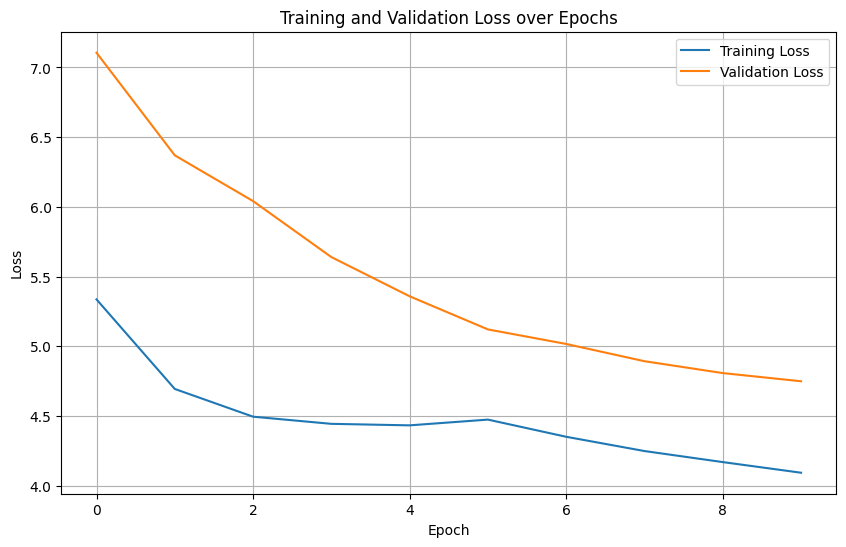

In [109]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(validation_losses, label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### 어텐션 맵 시각화
훈련이 완료된 후, 특정 문장에 대한 번역 과정에서 모델의 어텐션 분포를 시각화하여 어떤 단어에 주로 집중했는지 확인할 수 있습니다.

In [110]:
def plot_attention(attention_plot, sentence, translated_tokens):
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(1, 1, 1)
    ax.matshow(attention_plot, cmap='viridis')

    # fontprop 객체를 fontdict에 직접 포함하여 명시적으로 폰트 지정
    fontdict = {'fontsize': 14, 'fontproperties': fontprop}

    ax.set_xticklabels([''] + sentence.split(' '), fontdict=fontdict, rotation=90)
    ax.set_yticklabels([''] + translated_tokens, fontdict=fontdict)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.xlabel('Input (Korean)', fontproperties=fontprop)
    plt.ylabel('Output (English)', fontproperties=fontprop)
    plt.title('Attention Weights', fontproperties=fontprop)
    plt.show()

print("Attention plot function defined.")

Attention plot function defined.


Original Korean: 오바마는 대통령이다.
Processed Korean: 오바마 는 대통령 이 다 .
Translated English: obama is president president barack obama president barack obama president barack obama . president barack obama . president barack obama . obama . president barack obama president barack obama . <end>


/tmp/ipykernel_131125/2046871734.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence.split(' '), fontdict=fontdict, rotation=90)
/tmp/ipykernel_131125/2046871734.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + translated_tokens, fontdict=fontdict)


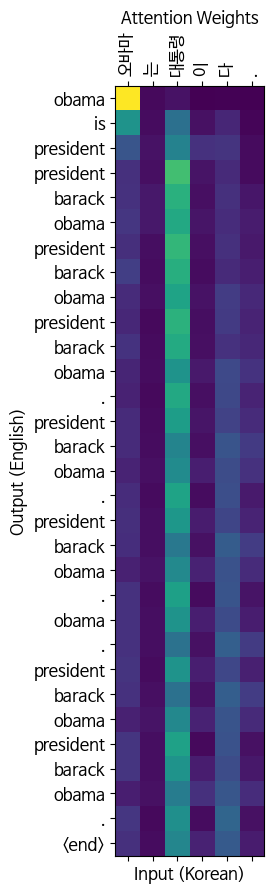

Attention map visualization complete for an example sentence.


In [111]:
# 훈련이 끝난 후, 예시 문장 중 하나를 선택하여 어텐션 맵을 시각화합니다.
example_sentence_for_attention = example_sentences_kor[0] # 첫 번째 예시 문장 선택

translated_result, processed_kor_sentence, attention_plot = translate_sentence(
    example_sentence_for_attention,
    seq2seq_model, # changed from encoder, decoder to seq2seq_model
    kor_tokenizer,
    eng_tokenizer,
    max_eng_len,
    device
)

print(f"Original Korean: {example_sentence_for_attention}")
print(f"Processed Korean: {processed_kor_sentence}")
print(f"Translated English: {' '.join(translated_result)}")

# <end> 토큰이 있을 경우, 그 이전까지의 번역 토큰만 전달
if '<end>' in translated_result:
    translated_tokens_for_plot = translated_result[:translated_result.index('<end>') + 1]
else:
    translated_tokens_for_plot = translated_result

plot_attention(attention_plot.numpy(), processed_kor_sentence, translated_tokens_for_plot)

print("Attention map visualization complete for an example sentence.")